# Proyecto 1 Deep Learning
## María Fernanda García Villavicencio 

**Base de datos:** Room Occupancy Estimation \\


Es una base de datos que estima el número de habitantes en una habitación basandose en sensores como la temperatura, la luz, el sonido, los niveles de CO2 y PIR.

Considero que la base de datos cuenta con suficientes datos para entrenar una red neuronal, además de que sigue una secuencia temporal en donde se puede aplicar un modelo LSTM.

In [3]:
# Librerias a utilizar 
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

In [4]:
# Cargar los datos de entrenamiento
data = pd.read_csv('Occupancy_Estimation.csv')
data.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [5]:
data.info() # Al parecer la base de datos ya se encuentra limpia 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10129 non-null  object 
 1   Time                  10129 non-null  object 
 2   S1_Temp               10129 non-null  float64
 3   S2_Temp               10129 non-null  float64
 4   S3_Temp               10129 non-null  float64
 5   S4_Temp               10129 non-null  float64
 6   S1_Light              10129 non-null  int64  
 7   S2_Light              10129 non-null  int64  
 8   S3_Light              10129 non-null  int64  
 9   S4_Light              10129 non-null  int64  
 10  S1_Sound              10129 non-null  float64
 11  S2_Sound              10129 non-null  float64
 12  S3_Sound              10129 non-null  float64
 13  S4_Sound              10129 non-null  float64
 14  S5_CO2                10129 non-null  int64  
 15  S5_CO2_Slope       

In [6]:
# Limpieza de datos (eliminar las columnas que no se utilizarán)
if 'Time' in data.columns:
    data = data.drop(columns=['Time'])
if 'Date' in data.columns:
    data = data.drop(columns=['Date'])

In [7]:
data.columns

Index(['S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light', 'S2_Light',
       'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound', 'S4_Sound',
       'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR', 'Room_Occupancy_Count'],
      dtype='object')

In [8]:
#Separar variable predictora
X = data.drop(columns=['Room_Occupancy_Count'])  
y = data['Room_Occupancy_Count']
X.shape, y.shape

((10129, 16), (10129,))

In [15]:
scaler = MinMaxScaler()
X_scaled1 = scaler.fit_transform(X)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_scaled1, y, test_size=0.2, random_state=42)
print(X_train1.shape, X_test1.shape, y_train1.shape, y_test1.shape)

(8103, 16) (2026, 16) (8103,) (2026,)


# Entrenamiento del modelo

Usé una red neuronal simple, de un modelo llamado Dense

In [17]:
# Overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5)

In [21]:
model_dense = Sequential([
    Dense(64, activation='relu', input_shape=(X_train1.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])
model_dense.compile(optimizer='adam', loss='mse')

In [23]:
#Entrenamiento
history_dense = model_dense.fit(
    X_train1, y_train1,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4377 - val_loss: 0.0958
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0735 - val_loss: 0.0701
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0437 - val_loss: 0.0550
Epoch 4/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0295 - val_loss: 0.0510
Epoch 5/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0222 - val_loss: 0.0446
Epoch 6/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0205 - val_loss: 0.0386
Epoch 7/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0148 - val_loss: 0.0399
Epoch 8/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0145 - val_loss: 0.0307
Epoch 9/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0149 - val_loss: 0.0308
Epoch 10/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0108 - val_loss: 0.0281
Epoch 11/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0127 - val_loss: 0.0227
Epoch 12/100
203/203 ━━━━━━━━━━━━━━━━━━━━

In [27]:
#Evaluación del primer modelo 
y_pred_dense = model_dense.predict(X_test1)

print("MSE:", mean_squared_error(y_test1, y_pred_dense))
print("MAE:", mean_absolute_error(y_test1, y_pred_dense))
print("R2 Score:", r2_score(y_test1, y_pred_dense))

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE: 0.011504729956483706
MAE: 0.03530400832112868
R2 Score: 0.9859717488288879


In [108]:
# Escalado de datos
scaler = MinMaxScaler()
X_scaled2 = scaler.fit_transform(X)

# Crear secuencias de temporales, datos para el entrenamiento
def create_dataset(dataset_X, dataset_y, look_back=10):
    X_seq, y_seq = [], []
    for i in range(len(dataset_X) - look_back):
        X_seq.append(dataset_X[i:i+look_back])
        y_seq.append(dataset_y[i + look_back])
    return np.array(X_seq), np.array(y_seq)

X_new, y_new = create_dataset(X_scaled2, y, 10)

In [110]:
# División de datos
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_new, y_new, test_size=0.2, random_state=19)
print(X_train2.shape, X_test2.shape, y_train2.shape, y_test2.shape)

(8095, 10, 16) (2024, 10, 16) (8095,) (2024,)


In [112]:
# Overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5)
model_lstm = Sequential([
    LSTM(100, input_shape=(X_train2.shape[1], X_train2.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    Dense(1)
])

model_lstm.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

In [122]:
# Entrenamiento 
history_lstm = model_lstm.fit(
    X_train2, y_train2,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0045 - val_loss: 0.0023
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0045 - val_loss: 0.0037
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0060 - val_loss: 0.0023
Epoch 4/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0073 - val_loss: 0.0033
Epoch 5/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0071 - val_loss: 0.0024
Epoch 6/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0029 - val_loss: 0.0023
Epoch 7/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0064 - val_loss: 0.0028
Epoch 8/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0083 - val_loss: 0.0025


In [124]:
model_dense.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,605 (37.52 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,404 (25.02 KB)

In [126]:
model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 10, 100)             │          46,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 10, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 100)                 │          80,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 381,905 (1.46 MB)

 Trainable params: 127,301 (497.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 254,604 (994.55 KB)

# Predicción 

In [233]:
y_pred_lstm = model_lstm.predict(X_test2).flatten()

print("MSE:", mean_squared_error(y_test2, y_pred_lstm))
print("MAE:", mean_absolute_error(y_test2, y_pred_lstm))
print("R2:", r2_score(y_test2, y_pred_lstm))

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MSE: 0.0026525988904339656
MAE: 0.00826120029089479
R2: 0.9966530203819275


In [275]:

look_back = 10
n_features = X.shape[1]

real_scaled = X_test1[:100]  
entrada_concatenada = np.vstack([X_scaled2[-look_back:], real_scaled])

entrada_y = y.iloc[-(len(real_scaled) + look_back):].values

X_real, y_real = create_dataset(entrada_concatenada, entrada_y, look_back)

# Predicciones
predictions = model_lstm.predict(X_real).flatten()

real_demand = y_real


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


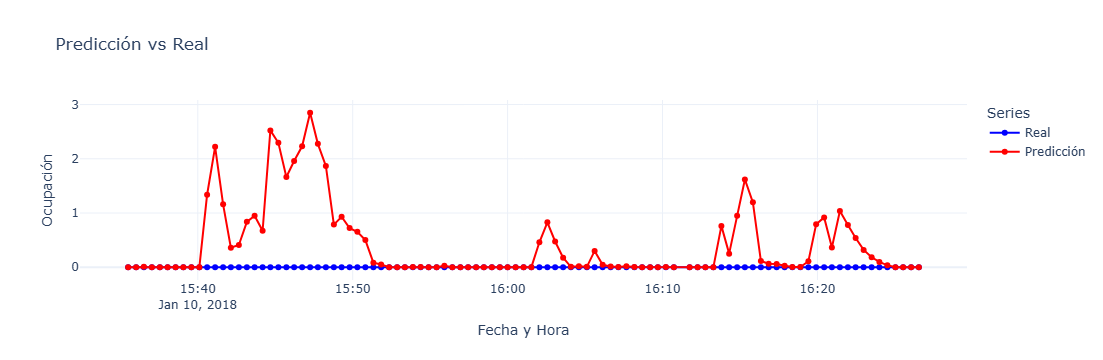

In [277]:
# Cargar los datos de entrenamiento
dataA = pd.read_csv('Occupancy_Estimation.csv')
dataA['Date'] = dataA['Date'].astype(str)
dataA['Time'] = dataA['Time'].astype(str)
dataA['datetime'] = pd.to_datetime(dataA['Date'] + ' ' + dataA['Time'], format='%Y/%m/%d %H:%M:%S')
real_index = dataA['datetime'].iloc[-len(X_test1):][:len(predictions)]
# Series alineadas con fechas reales
pred_series = pd.Series(predictions, index=real_index)
real_series = pd.Series(y_real, index=real_index)

fig = go.Figure()
fig.add_trace(go.Scatter(x=real_series.index, y=real_series, mode='lines+markers',
                         name='Real', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=pred_series.index, y=pred_series, mode='lines+markers',
                         name='Predicción', line=dict(color='red')))

fig.update_layout(
    title='Predicción vs Real ',
    xaxis_title='Fecha y Hora',
    yaxis_title='Ocupación',
    legend_title='Series',
    template='plotly_white'
)

fig.show()

# Uso de optimizadores

Se utilizó el optimizador Adam debido a su capacidad de adaptarse dinámicamente a cada parámetro del modelo, lo cual es especialmente útil en un conjunto de datos multivariado y secuencial como el de estimación de ocupación. Adam facilita la convergencia del modelo LSTM, estabiliza el proceso de entrenamiento frente a gradientes ruidosos, y permite obtener resultados satisfactorios sin una gran carga de ajuste manual de hiperparámetros. Estas características lo convierten en una excelente elección para este tipo de problema.